# Feature Selection

### In this tutorial, we will select the most relevant features in our data.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif

In [2]:
# insert here the path to your file
with open('resp_events.pkl', 'rb') as f:
    resp_events = pickle.load(f)

print('N. resp events', len(resp_events))
resp_labels=np.load("resp_labels.npy") 
print('N. resp labels', len(resp_labels))
resp_feat=np.load("resp_feat.npy") 
print('N. features', len(resp_feat[0]))


N. resp events 17414
N. resp labels 10000
N. features 10


In [4]:
# Generate dummy data to perform simulation
n_events = 10000 
n_features = 10 

# unbalanced ratio (80% normal events (0), 20% apnea events (1))
non_apnea_ratio = 0.8
n_nonapnea = int(n_events * non_apnea_ratio)
n_apnea = n_events - n_nonapnea

print(f"Generation of {n_events} events")
print(f"Non apnea Events (Class 0): {n_nonapnea} (80%)")
print(f"Apnea Events (Class 1): {n_apnea} (20%)")

# generate labels and shuffle them
labels_non_apnea = np.zeros(n_nonapnea, dtype=int)
labels_apnea = np.ones(n_apnea, dtype=int)
resp_labels = np.concatenate([labels_non_apnea, labels_apnea])

np.random.shuffle(resp_labels)


# Generate random features for all events using a normal distribution
# to simulate real data
resp_feat = np.random.randn(n_events, n_features).astype(np.float32)

idx_sel = [0, 3, 7, 9]
resp_feat = resp_feat[:, idx_sel]
print('N. features', len(resp_feat[0]))

# Generate random respiratory events value with different length 
resp_events = []
# define an interval for the lenghts of this respiratory events
min_len = 22 
max_len = 35 

for i in range(n_events):
    length = np.random.randint(min_len, max_len + 1)
    
    # generate a temporal serie: sin + noise to simulate our normalized values
    t = np.linspace(0, 2 * np.pi, length)
    
    # for apnea events the signal should be more flat (less nopise)
    if resp_labels[i] == 1:
        signal = 0.1 * np.sin(t * 2) + 0.5 + 0.05 * np.random.randn(length)
    else:
        signal = 0.5 * np.sin(t * 3) + 1.0 + 0.1 * np.random.randn(length)

    resp_events.append(signal.astype(np.float32))


Generation of 10000 events
Non apnea Events (Class 0): 8000 (80%)
Apnea Events (Class 1): 2000 (20%)
N. features 4


## Inspection of the correlated features
### Check which features are highly correlated by looking at the correlation matrix. The statistical relevance to the target variable of each feature is then assessed trough an ANOVA F-test.

In [5]:
X = resp_feat
y = resp_labels

feature_names = [f'feature_{i}' for i in range(X.shape[1])]
X_df = pd.DataFrame(X, columns=feature_names)

print("--- Original Set of data with 10 features---")
print(X_df.head())
print("-" * 60)

--- Original Set of data with 10 features---
   feature_0  feature_1  feature_2  feature_3
0  -1.108814  -0.230890  -0.891248  -0.032726
1   0.889042   0.236037   0.317014  -0.317660
2   0.169192  -0.373757   1.786432  -0.860792
3  -0.222366  -0.335197  -1.779857   0.496170
4  -0.488781  -0.216726  -1.127831  -0.222459
------------------------------------------------------------


### Evaluate the importance of each feature with respect to the target y using an ANOVA-F test. We will obtain the relevance values for each feature.

In [6]:
f_scores, p_values = f_classif(X_df, y)
relevance_scores = pd.DataFrame({
    'feature': feature_names,
    'relevance_score': f_scores
}).sort_values(by='relevance_score', ascending=False).reset_index(drop=True)
print("--- Relevance Scores (Feature-Target) ---")
print(relevance_scores)
print("-" * 60)

--- Relevance Scores (Feature-Target) ---
     feature  relevance_score
0  feature_0         1.234585
1  feature_1         0.576115
2  feature_3         0.480842
3  feature_2         0.323162
------------------------------------------------------------


### Correlation matrix between features
### This is needed to understand redundancy in data features.

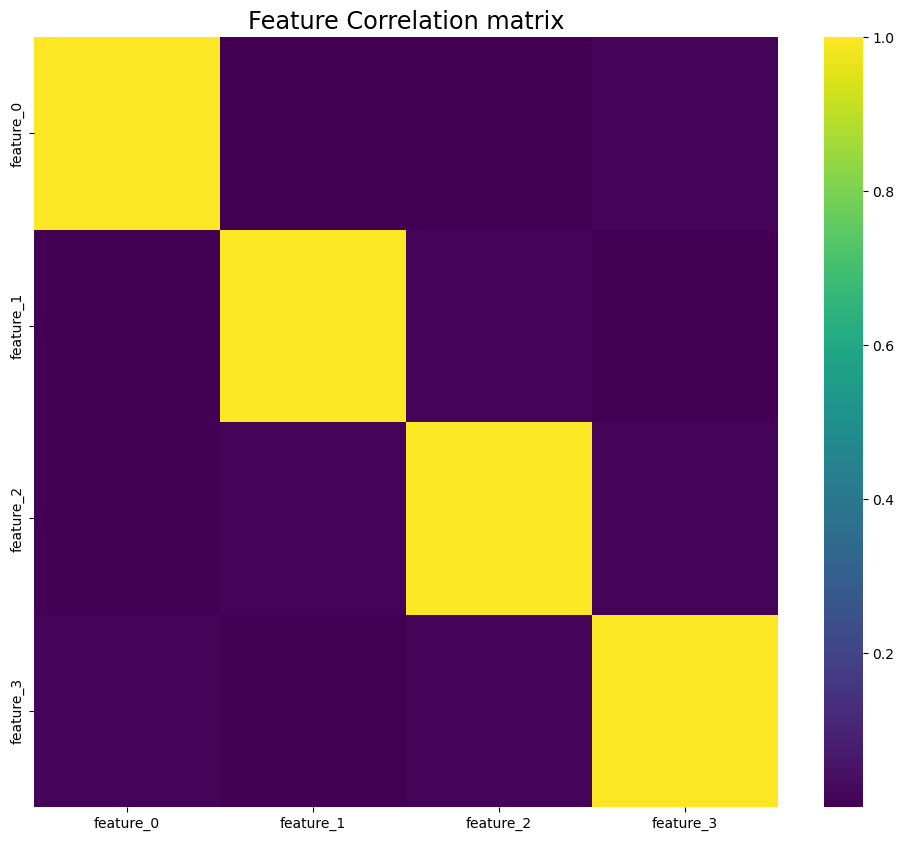

In [7]:
correlation_matrix = X_df.corr().abs()
# Visualizziamo la matrice di correlazione per avere un'idea
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='viridis')
#plt.xticks(fontsize=12)
#plt.yticks(fontsize=12)
plt.title('Feature Correlation matrix', fontsize='xx-large')
plt.show()

### Implement a selection Threshold
### We need to implement a criteria to select a subset of features relavant to the target variable and uncorrelated (or weakly correlated). 
### We thus define a threshold and all the features with a correlation score above it will be consider redundant.

In [8]:
correlation_threshold = 0.7
selected_features = []
# order features by relevance
sorted_features_by_relevance = relevance_scores['feature'].tolist()
for current_feature in sorted_features_by_relevance:
    is_redundant = False
    if not selected_features:
        #first feature = most relevant
        selected_features.append(current_feature)
    else:
        # for subsequent features, the correlation score will be checked
        for selected_feature in selected_features:
            corr_value = correlation_matrix.loc[current_feature, selected_feature]
            if corr_value >= correlation_threshold:
                is_redundant = True
                break  
        if not is_redundant:
            selected_features.append(current_feature)

print("--- Result ---")
print(f"Correlation Threshold: {correlation_threshold}")
print(f"N. Initial Features: {X_df.shape[1]}")
print(f"N. Selected Features: {len(selected_features)}")
print(f"Selected Features: {selected_features}")


--- Result ---
Correlation Threshold: 0.7
N. Initial Features: 4
N. Selected Features: 4
Selected Features: ['feature_0', 'feature_1', 'feature_3', 'feature_2']
